In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/vipoooool
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___healthy
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Grape___healthy
/kaggle/input/

In [6]:
import os

for dirname, dirs, files in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/vipoooool
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___healthy
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Grape___healthy
/kaggle/input/

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

valid_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

validation_set = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [9]:
import tensorflow as tf

model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(128,128,3)),  # ✅ Proper way

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(38, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1777655670.945035     152 service.cc:152] XLA service 0x7b7d380094e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777655670.945088     152 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777655671.274195     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


   3/2197 ━━━━━━━━━━━━━━━━━━━━ 2:57 81ms/step - accuracy: 0.0312 - loss: 5.4701 

I0000 00:00:1777655673.693296     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 385s 174ms/step - accuracy: 0.5539 - loss: 1.6080 - val_accuracy: 0.8351 - val_loss: 0.5216
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 135s 61ms/step - accuracy: 0.9051 - loss: 0.2971 - val_accuracy: 0.9015 - val_loss: 0.3115
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 0.9502 - loss: 0.1480 - val_accuracy: 0.8960 - val_loss: 0.3634
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 134s 61ms/step - accuracy: 0.9716 - loss: 0.0876 - val_accuracy: 0.8989 - val_loss: 0.3717
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 133s 60ms/step - accuracy: 0.9784 - loss: 0.0641 - val_accuracy: 0.8731 - val_loss: 0.5439
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 0.9818 - loss: 0.0566 - val_accuracy: 0.8899 - val_loss: 0.5021
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 133s 60ms/step - accuracy: 0.9837 - loss: 0.0486 - val_accuracy: 0.8989 - val_loss: 0.5024
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 0.9882 - l

In [12]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Train Accuracy: 0.9869123101234436
Validation Accuracy: 0.904962420463562


In [13]:
print("Train Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])

Train Loss: 0.04263192042708397
Validation Loss: 0.511941134929657


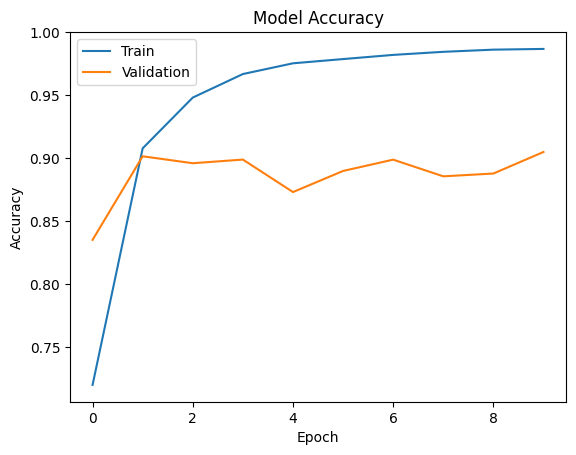

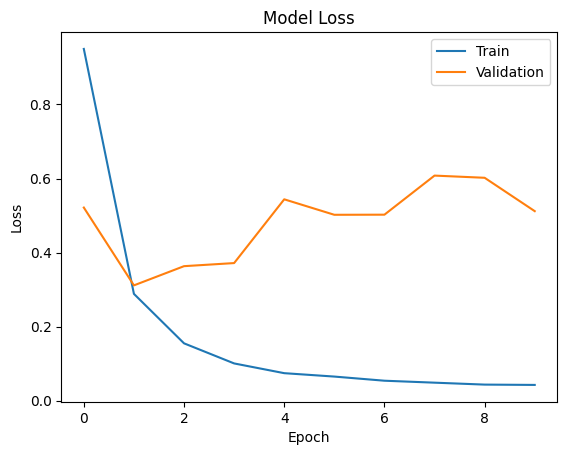

In [14]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

validation_set.reset()

y_pred = model.predict(validation_set)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_set.classes

print(classification_report(y_true, y_pred_classes))

550/550 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step
              precision    recall  f1-score   support

           0       0.04      0.03      0.03       504
           1       0.02      0.02      0.02       497
           2       0.02      0.02      0.02       440
           3       0.02      0.02      0.02       502
           4       0.03      0.03      0.03       454
           5       0.01      0.01      0.01       421
           6       0.02      0.02      0.02       456
           7       0.02      0.01      0.02       410
           8       0.03      0.03      0.03       477
           9       0.02      0.02      0.02       477
          10       0.02      0.02      0.02       465
          11       0.03      0.03      0.03       472
          12       0.02      0.02      0.02       480
          13       0.02      0.02      0.02       430
          14       0.02      0.02      0.02       423
          15       0.03      0.03      0.03       503
          16       0.03      0.03     

In [16]:
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

[[16 14 12 ... 15 16 16]
 [15  9  8 ... 22 13  9]
 [ 8 10  9 ... 14  9  9]
 ...
 [13 14 15 ... 13 11 19]
 [12 12 13 ... 10 10 14]
 [20 16 13 ... 10 11  9]]


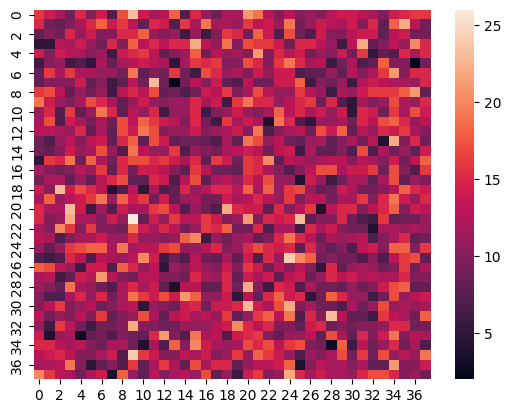

In [17]:
import seaborn as sns

sns.heatmap(cm)
plt.show()

In [18]:
model.save("trained_plant_disease_model.keras")